# Sehat-AI | Chest X-ray Validator v2
### Key fix over v2: negative class now includes **other body-part X-rays** (hand, wrist, elbow, shoulder, finger, forearm, humerus, knee)
This forces the model to learn **chest-specific anatomy** (lung fields, cardiac silhouette, diaphragm, rib cage) rather than just "is this a radiological image?"

**Negative class composition:**
- MURA dataset — 7 musculoskeletal X-ray types (Stanford)
- Intel Image Classification — natural scenes
- Brain MRI (Navoneel)
- Abdominal X-rays (from NIH or Kaggle)

**Architecture:** EfficientNetB0 (upgraded from MobileNetV2 for better feature separation)

In [2]:
# ── 0. Install & imports ──────────────────────────────────────────────────────
!pip install tensorflow kaggle pillow scikit-learn seaborn -q

import os, shutil, random, json, io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score
from PIL import Image

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow: 2.19.0
GPU: []


In [3]:
# ── 1. Kaggle auth ────────────────────────────────────────────────────────────
from google.colab import files
files.upload()  # upload kaggle.json

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/kaggle.json')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')
print("Kaggle auth configured.")

Saving kaggle.json to kaggle.json
Kaggle auth configured.


In [4]:
# ── 2. Download datasets ──────────────────────────────────────────────────────
# Positive class
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/raw/ --unzip -q

# Negative: natural scenes
!kaggle datasets download -d puneet6060/intel-image-classification -p /content/raw/ --unzip -q

# Negative: brain MRI
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection -p /content/raw/ --unzip -q

# Negative: OTHER X-RAY TYPES (musculoskeletal) — KEY FIX
# MURA: hand, wrist, elbow, shoulder, finger, forearm, humerus
!kaggle datasets download -d cjinny/mura-v11 -p /content/raw/ --unzip -q

# Negative: knee X-rays (additional body part)
!kaggle datasets download -d tommyngx/kneeoa -p /content/raw/knee/ --unzip -q

print("\nAll datasets downloaded.")

# List what we got
!ls /content/raw/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
Dataset URL: https://www.kaggle.com/datasets/cjinny/mura-v11
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/tommyngx/kneeoa
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)

All datasets downloaded.
brain_tumor_dataset  knee	no	  seg_test   yes
chest_xray	     MURA-v1.1	seg_pred  seg_train


In [5]:
# ── 3. Build dataset ──────────────────────────────────────────────────────────
DATASET_DIR = Path('/content/dataset')
POS_DIR = DATASET_DIR / 'chest_xray'
NEG_DIR = DATASET_DIR / 'not_xray'

POS_DIR.mkdir(parents=True, exist_ok=True)
NEG_DIR.mkdir(parents=True, exist_ok=True)

def collect_images(folder, extensions=('*.jpg', '*.jpeg', '*.png')):
    imgs = []
    p = Path(folder)
    if p.exists():
        for ext in extensions:
            imgs += list(p.rglob(ext))
    return imgs

def copy_images(paths, dest_dir, prefix, limit=None):
    random.shuffle(paths)
    selected = paths[:limit] if limit else paths
    for i, p in enumerate(selected):
        try:
            shutil.copy(p, dest_dir / f"{prefix}_{i}{p.suffix}")
        except Exception:
            pass
    return len(selected)

# ── POSITIVES: chest X-rays ──────────────────────────────────────────────────
xray_imgs = []
for sub in ['train/NORMAL', 'train/PNEUMONIA', 'test/NORMAL', 'test/PNEUMONIA', 'val/NORMAL', 'val/PNEUMONIA']:
    xray_imgs += collect_images(f'/content/raw/chest_xray/{sub}')

n_pos = copy_images(xray_imgs, POS_DIR, 'chest', limit=2500)
print(f"Chest X-rays copied: {n_pos}")

# ── NEGATIVES ────────────────────────────────────────────────────────────────

# 1. MURA musculoskeletal X-rays (MOST IMPORTANT negative class)
# MURA folder structure: MURA-v1.1/train/XR_HAND/patient.../study.../image.png
mura_base = Path('/content/raw/MURA-v1.1')
if not mura_base.exists():
    mura_base = Path('/content/raw')  # fallback

body_parts = ['XR_HAND', 'XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER', 'XR_FINGER', 'XR_FOREARM', 'XR_HUMERUS']
mura_imgs = []
for part in body_parts:
    part_path = mura_base / 'train' / part
    if part_path.exists():
        part_imgs = collect_images(str(part_path))
        mura_imgs += part_imgs
        print(f"  {part}: {len(part_imgs)} images found")

n_mura = copy_images(mura_imgs, NEG_DIR, 'mura', limit=1500)
print(f"MURA X-rays copied: {n_mura}")

# 2. Knee X-rays
knee_imgs = collect_images('/content/raw/knee')
n_knee = copy_images(knee_imgs, NEG_DIR, 'knee', limit=400)
print(f"Knee X-rays copied: {n_knee}")

# 3. Brain MRI
brain_imgs = [
    p for p in Path('/content/raw').rglob('*.jpg')
    if any(k in str(p).lower() for k in ['brain', 'tumor', 'mri'])
    and 'chest_xray' not in str(p)
    and 'seg_' not in str(p)
]
brain_imgs += list(Path('/content/raw').rglob('*.jpeg'))
brain_imgs = [p for p in brain_imgs if 'brain' in str(p).lower() or 'tumor' in str(p).lower()]
n_brain = copy_images(brain_imgs, NEG_DIR, 'brain', limit=400)
print(f"Brain MRI copied: {n_brain}")

# 4. Natural scenes (Intel)
intel_base = Path('/content/raw/seg_train/seg_train')
if not intel_base.exists():
    intel_base = Path('/content/raw/seg_train')
intel_imgs = []
if intel_base.exists():
    for folder in intel_base.iterdir():
        if folder.is_dir():
            intel_imgs += list(folder.glob('*.jpg')) + list(folder.glob('*.jpeg'))
n_intel = copy_images(intel_imgs, NEG_DIR, 'intel', limit=700)
print(f"Intel scenes copied: {n_intel}")

# ── Summary ──────────────────────────────────────────────────────────────────
total_pos = len(list(POS_DIR.iterdir()))
total_neg = len(list(NEG_DIR.iterdir()))
print(f"\n{'='*50}")
print(f"POSITIVES (chest_xray) : {total_pos}")
print(f"NEGATIVES (not_xray)   : {total_neg}")
print(f"  - MURA X-rays        : ~{n_mura}")
print(f"  - Knee X-rays        : ~{n_knee}")
print(f"  - Brain MRI          : ~{n_brain}")
print(f"  - Natural scenes     : ~{n_intel}")
print(f"Ratio (pos:neg)        : {total_pos/total_neg:.2f}")
print(f"{'='*50}")

Chest X-rays copied: 2500
  XR_HAND: 5543 images found
  XR_WRIST: 9756 images found
  XR_ELBOW: 4931 images found
  XR_SHOULDER: 8379 images found
  XR_FINGER: 5106 images found
  XR_FOREARM: 1825 images found
  XR_HUMERUS: 1272 images found
MURA X-rays copied: 1500
Knee X-rays copied: 400
Brain MRI copied: 177
Intel scenes copied: 700

POSITIVES (chest_xray) : 2500
NEGATIVES (not_xray)   : 2777
  - MURA X-rays        : ~1500
  - Knee X-rays        : ~400
  - Brain MRI          : ~177
  - Natural scenes     : ~700
Ratio (pos:neg)        : 0.90


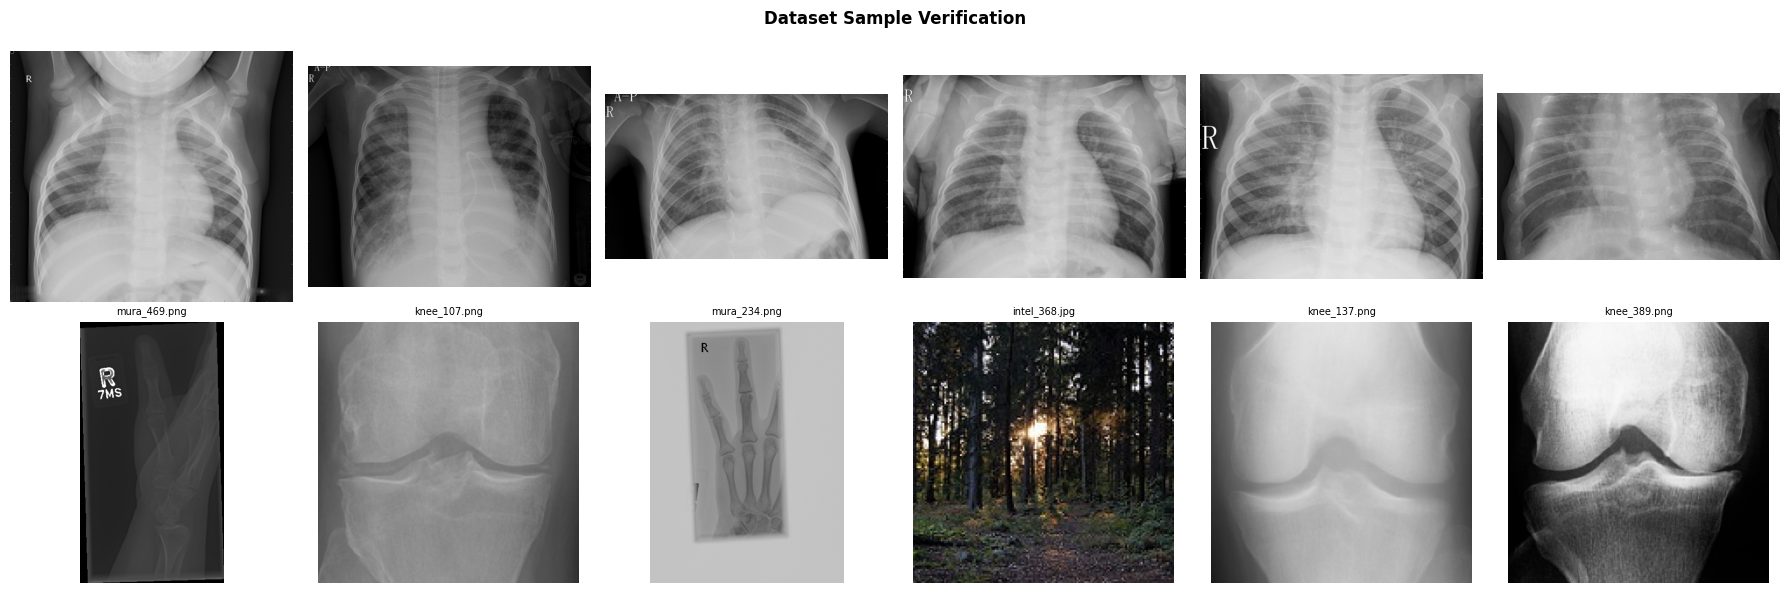

In [6]:
# ── 4. Verify dataset visually ────────────────────────────────────────────────
# Show sample images from each negative type so you can confirm they loaded correctly
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes[0][0].set_ylabel('chest_xray', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('not_xray', fontsize=10, fontweight='bold')

pos_samples = random.sample(list(POS_DIR.iterdir()), 6)
neg_samples = random.sample(list(NEG_DIR.iterdir()), 6)

for i, (p, n) in enumerate(zip(pos_samples, neg_samples)):
    try:
        axes[0][i].imshow(Image.open(p).convert('RGB'))
        axes[0][i].axis('off')
    except Exception:
        axes[0][i].axis('off')
    try:
        axes[1][i].imshow(Image.open(n).convert('RGB'))
        axes[1][i].set_title(n.name[:15], fontsize=7)
        axes[1][i].axis('off')
    except Exception:
        axes[1][i].axis('off')

plt.suptitle('Dataset Sample Verification', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dataset_samples.png', dpi=100)
plt.show()

In [7]:
# ── 5. Data generators ────────────────────────────────────────────────────────
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# EfficientNet expects inputs in [0, 255] range — do NOT rescale
# EfficientNetB0 has built-in rescaling in its preprocessing layer
# Use tf.keras.applications.efficientnet.preprocess_input instead

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    str(DATASET_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    str(DATASET_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices:", train_gen.class_indices)
print("Training samples:", train_gen.n)
print("Validation samples:", val_gen.n)
# NOTE: chest_xray=0, not_xray=1 (alphabetical order)
# Model sigmoid output = P(not_xray)
# score < threshold → chest X-ray → PASS
# score >= threshold → not chest X-ray → REJECT

Found 4222 images belonging to 2 classes.
Found 1055 images belonging to 2 classes.
Class indices: {'chest_xray': 0, 'not_xray': 1}
Training samples: 4222
Validation samples: 1055


In [8]:
# ── 6. Handle class imbalance ─────────────────────────────────────────────────
# If negatives >> positives, compute class weights
n_chest = total_pos
n_other = total_neg
total = n_chest + n_other

# chest_xray=0, not_xray=1
class_weight = {
    0: total / (2 * n_chest),  # weight for chest_xray class
    1: total / (2 * n_other)   # weight for not_xray class
}
print("Class weights:", class_weight)

Class weights: {0: 1.0554, 1: 0.9501260352898812}


In [9]:
# ── 7. Build model (EfficientNetB0) ───────────────────────────────────────────
def build_model():
    base = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # freeze for Phase 1

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,423,844 (16.88 MB)

 Trainable params: 371,713 (1.42 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [10]:
# ── 8. Phase 1: Train frozen base ─────────────────────────────────────────────
callbacks_phase1 = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_phase1.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

print("Phase 1: Training classification head (frozen base)...")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_phase1,
    class_weight=class_weight
)
print("Phase 1 complete.")

Phase 1: Training classification head (frozen base)...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9495 - auc: 0.9862 - loss: 0.1011 - precision: 0.9349 - recall: 0.9814
Epoch 1: val_auc improved from None to 1.00000, saving model to /content/best_phase1.keras

Epoch 1: finished saving model to /content/best_phase1.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 457s 3s/step - accuracy: 0.9874 - auc: 0.9991 - loss: 0.0303 - precision: 0.9822 - recall: 0.9941 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0081 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9989 - auc: 1.0000 - loss: 0.0036 - precision: 0.9989 - recall: 0.9991
Epoch 2: val_auc did not improve from 1.00000
132/132 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.9974 - auc: 0.9997 - loss: 0.0082 - precision: 0.9973 - recall: 0.9977 - val_accuracy: 0.9924 - val_auc: 1.0000 - val_loss: 0.0263 - val_precision: 1.0000 - val_r

In [11]:
# ── 9. Phase 2: Fine-tune last 50 layers ──────────────────────────────────────
# EfficientNetB0 has more layers than MobileNetV2 — unfreeze last 50
model.load_weights('/content/best_phase1.keras')

base_model = model.layers[1]  # EfficientNetB0 is layer index 1 in functional API
base_model.trainable = True
# Freeze all except last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning {trainable_count} layers in base model")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_auc', patience=6, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_phase2.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

print("Phase 2: Fine-tuning...")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_phase2,
    class_weight=class_weight
)
print("Phase 2 complete.")

Fine-tuning 50 layers in base model
Phase 2: Fine-tuning...
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9748 - auc: 0.9978 - loss: 0.0725 - precision: 0.9597 - recall: 0.9935
Epoch 1: val_auc improved from None to 1.00000, saving model to /content/best_phase2.keras

Epoch 1: finished saving model to /content/best_phase2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 582s 4s/step - accuracy: 0.9818 - auc: 0.9987 - loss: 0.0516 - precision: 0.9706 - recall: 0.9955 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0037 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9887 - auc: 0.9981 - loss: 0.0400 - precision: 0.9830 - recall: 0.9949
Epoch 2: val_auc did not improve from 1.00000
132/132 ━━━━━━━━━━━━━━━━━━━━ 557s 4s/step - accuracy: 0.9919 - auc: 0.9984 - loss: 0.0299 - precision: 0.9901 - recall: 0.9946 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0045 - val_precision: 1.000

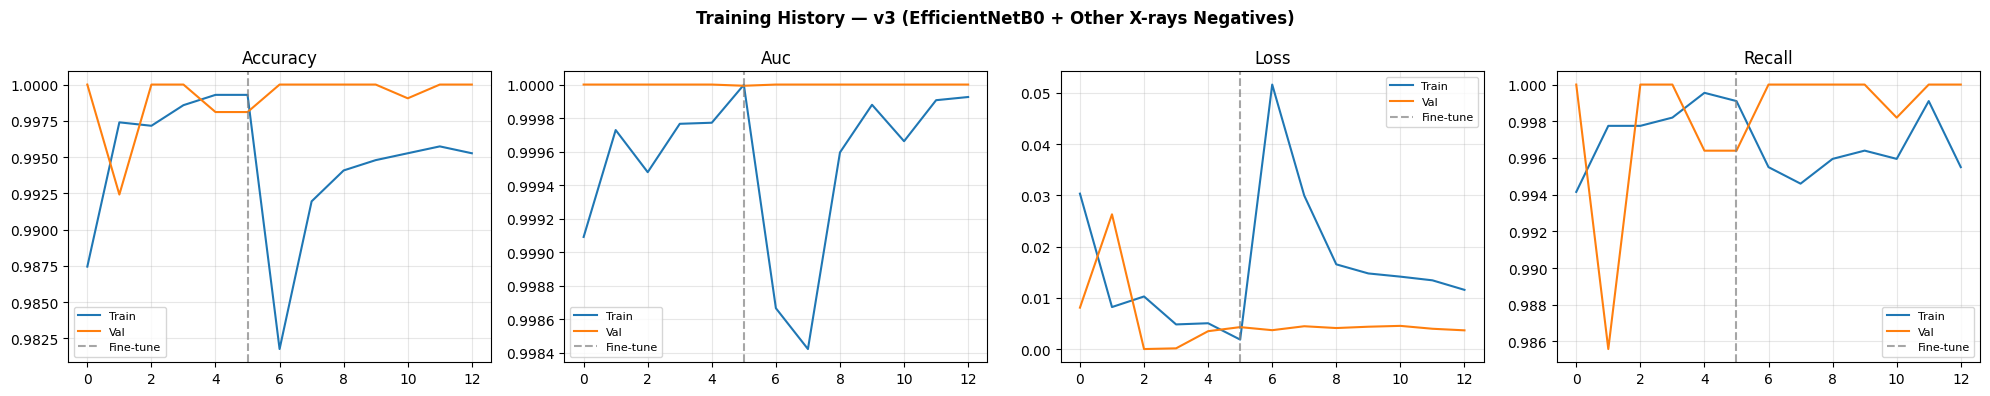

In [12]:
# ── 10. Training curves ───────────────────────────────────────────────────────
model.load_weights('/content/best_phase2.keras')

def combine(h1, h2, key):
    return h1.history[key] + h2.history[key]

p1_len = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric in zip(axes, ['accuracy', 'auc', 'loss', 'recall']):
    ax.plot(combine(history1, history2, metric), label='Train')
    ax.plot(combine(history1, history2, f'val_{metric}'), label='Val')
    ax.axvline(x=p1_len - 1, color='gray', linestyle='--', alpha=0.7, label='Fine-tune')
    ax.set_title(metric.capitalize())
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Training History — v3 (EfficientNetB0 + Other X-rays Negatives)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves_v3.png', dpi=150)
plt.show()

In [13]:
# ── 11. Threshold analysis ────────────────────────────────────────────────────
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1).flatten()
y_true = val_gen.classes

# Class indices: chest_xray=0, not_xray=1
# sigmoid output = P(not_xray)
# score >= threshold → reject (not_xray)
# score < threshold → pass (chest_xray)

print(f"{'Threshold':>10} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>6} | {'F1':>6} | {'FN (xray rejected)':>18} | {'FP (non-xray passed)':>20}")
print("-" * 90)

results_table = []
for t in np.arange(0.20, 0.85, 0.05):
    y_pred = (y_pred_probs >= t).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    # cm[0][1] = FP: chest_xray predicted as not_xray (wrongly rejected)
    # cm[1][0] = FN: not_xray predicted as chest_xray (slipped through)
    fn = cm[0][1] if cm.shape == (2,2) else 0  # chest X-rays wrongly rejected
    fp = cm[1][0] if cm.shape == (2,2) else 0  # non-xrays that slipped through

    results_table.append((t, acc, prec, rec, f1, fn, fp))
    print(f"  {t:.2f}     | {acc:>8.3f} | {prec:>9.3f} | {rec:>6.3f} | {f1:>6.3f} | {fn:>18d} | {fp:>20d}")

# For a medical gatekeeper: prioritize keeping FN (wrongly rejected chest X-rays) = 0
# while minimizing FP (non-xrays slipping through)
# Find threshold where FN = 0 with lowest FP
zero_fn_results = [(t, acc, prec, rec, f1, fn, fp) for t, acc, prec, rec, f1, fn, fp in results_table if fn == 0]
if zero_fn_results:
    best = min(zero_fn_results, key=lambda x: x[6])  # lowest FP among FN=0
    print(f"\n✓ Recommended threshold: {best[0]:.2f} (FN={best[5]}, FP={best[6]}, F1={best[4]:.3f})")
    BEST_THRESHOLD = best[0]
else:
    # Fall back to best F1
    best = max(results_table, key=lambda x: x[4])
    print(f"\n✓ Best F1 threshold: {best[0]:.2f} (F1={best[4]:.3f})")
    BEST_THRESHOLD = best[0]

print(f"Selected threshold: {BEST_THRESHOLD:.2f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step
 Threshold | Accuracy | Precision | Recall |     F1 | FN (xray rejected) | FP (non-xray passed)
------------------------------------------------------------------------------------------
  0.20     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.25     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.30     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.35     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.40     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.45     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.50     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.55     |    1.000 |     1.000 |  1.000 |  1.000 |                  0 |                    0
  0.60

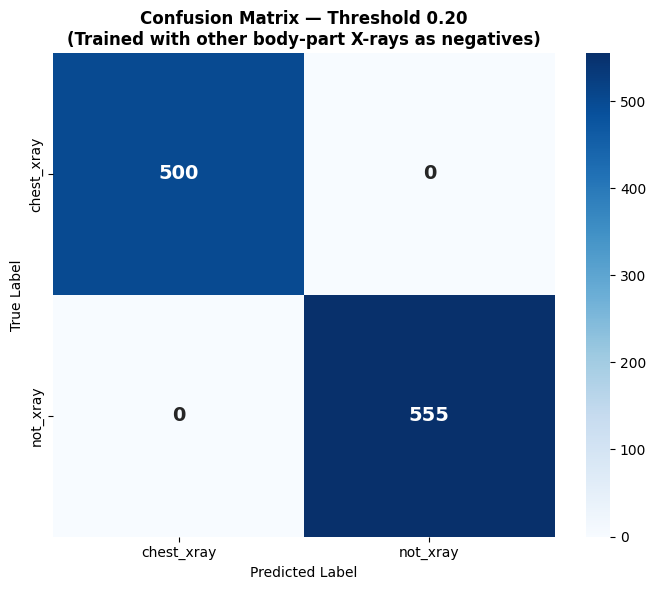


Classification Report:
              precision    recall  f1-score   support

  chest_xray       1.00      1.00      1.00       500
    not_xray       1.00      1.00      1.00       555

    accuracy                           1.00      1055
   macro avg       1.00      1.00      1.00      1055
weighted avg       1.00      1.00      1.00      1055


Detailed breakdown:
  ✓ Chest X-rays correctly passed   : 500
  ✗ Chest X-rays wrongly rejected   : 0  ← want this = 0
  ✓ Non-X-rays correctly rejected   : 555
  ✗ Non-X-rays that slipped through : 0  ← minimize this

Chest X-ray pass rate  : 100.00%
Non-X-ray reject rate  : 100.00%


In [14]:
# ── 12. Confusion matrix ──────────────────────────────────────────────────────
y_pred_final = (y_pred_probs >= BEST_THRESHOLD).astype(int)
cm = confusion_matrix(y_true, y_pred_final)
class_names = list(val_gen.class_indices.keys())  # ['chest_xray', 'not_xray']

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title(f'Confusion Matrix — Threshold {BEST_THRESHOLD:.2f}\n(Trained with other body-part X-rays as negatives)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_v3.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_final, target_names=class_names))

# Detailed cell explanation
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed breakdown:")
print(f"  ✓ Chest X-rays correctly passed   : {tn}")
print(f"  ✗ Chest X-rays wrongly rejected   : {fn}  ← want this = 0")
print(f"  ✓ Non-X-rays correctly rejected   : {tp}")
print(f"  ✗ Non-X-rays that slipped through : {fp}  ← minimize this")
print(f"\nChest X-ray pass rate  : {tn/(tn+fn)*100:.2f}%")
print(f"Non-X-ray reject rate  : {tp/(tp+fp)*100:.2f}%")

In [15]:
# ── 13. Per-category breakdown (optional debug) ───────────────────────────────
# Test how well the model handles each negative type separately
# This reveals if any specific body part X-ray type still slips through

print("Per-category validation on negatives:")
print("(Shows which body part X-ray types are hardest to reject)")
print("-" * 50)

neg_samples_all = list(NEG_DIR.iterdir())
prefixes = {'mura': 0, 'knee': 0, 'brain': 0, 'intel': 0}
correct = {'mura': 0, 'knee': 0, 'brain': 0, 'intel': 0}
total_counts = {'mura': 0, 'knee': 0, 'brain': 0, 'intel': 0}

for img_path in random.sample(neg_samples_all, min(400, len(neg_samples_all))):
    prefix = None
    for p in prefixes:
        if img_path.name.startswith(p):
            prefix = p
            break
    if prefix is None:
        continue

    try:
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        arr = tf.keras.applications.efficientnet.preprocess_input(np.array(img, dtype=np.float32))
        arr = np.expand_dims(arr, axis=0)
        score = float(model.predict(arr, verbose=0)[0][0])
        total_counts[prefix] += 1
        if score >= BEST_THRESHOLD:  # correctly rejected
            correct[prefix] += 1
    except Exception:
        pass

for prefix, cnt in total_counts.items():
    if cnt > 0:
        rate = correct[prefix] / cnt * 100
        bar = '█' * int(rate / 5) + '░' * (20 - int(rate / 5))
        print(f"  {prefix:10s}: [{bar}] {rate:.1f}% rejected ({correct[prefix]}/{cnt})")

print("\nAny type < 90% rejection rate needs more training data.")

Per-category validation on negatives:
(Shows which body part X-ray types are hardest to reject)
--------------------------------------------------
  mura      : [████████████████████] 100.0% rejected (229/229)
  knee      : [████████████████████] 100.0% rejected (49/49)
  brain     : [████████████████████] 100.0% rejected (26/26)
  intel     : [████████████████████] 100.0% rejected (96/96)

Any type < 90% rejection rate needs more training data.


In [16]:
# ── 14. Export model ──────────────────────────────────────────────────────────
# Save in both .h5 (legacy) and .keras (new format)
model.save('/content/chest_xray_validator_v3.h5')
model.save('/content/chest_xray_validator_v3.keras')
print("Models saved.")

# Evaluate final metrics
val_gen.reset()
eval_results = model.evaluate(val_gen, verbose=1)
metrics_dict = dict(zip(model.metrics_names, eval_results))
print("\nFinal metrics:", metrics_dict)

def get_metric(d, *keys):
    for k in keys:
        if k in d:
            return float(d[k])
    return None

metadata = {
    "model_name": "chest_xray_validator_v3",
    "version": "3.0",
    "architecture": "EfficientNetB0",
    "input_size": [224, 224],
    "preprocessing": "efficientnet.preprocess_input",
    "class_indices": train_gen.class_indices,
    "best_threshold": float(BEST_THRESHOLD),
    "val_accuracy": get_metric(metrics_dict, 'accuracy', 'compile_metrics/accuracy'),
    "val_auc": get_metric(metrics_dict, 'auc', 'compile_metrics/auc'),
    "val_precision": get_metric(metrics_dict, 'precision', 'compile_metrics/precision'),
    "val_recall": get_metric(metrics_dict, 'recall', 'compile_metrics/recall'),
    "trained_on": {
        "positives": "chest-xray-pneumonia (Kaggle)",
        "negatives": [
            "MURA v1.1 — hand, wrist, elbow, shoulder, finger, forearm, humerus X-rays (Stanford)",
            "Knee OA X-rays",
            "Brain MRI (Navoneel)",
            "Intel Image Classification — natural scenes"
        ]
    },
    "improvement_over_v2": "Added musculoskeletal and knee X-rays as negative class to enforce chest-specific anatomy learning"
}

with open('/content/chest_xray_validator_v3_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\nMetadata saved:")
print(json.dumps(metadata, indent=2))

Models saved.
33/33 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0037 - precision: 1.0000 - recall: 1.0000

Final metrics: {'loss': 0.003704811679199338, 'compile_metrics': 1.0}

Metadata saved:
{
  "model_name": "chest_xray_validator_v3",
  "version": "3.0",
  "architecture": "EfficientNetB0",
  "input_size": [
    224,
    224
  ],
  "preprocessing": "efficientnet.preprocess_input",
  "class_indices": {
    "chest_xray": 0,
    "not_xray": 1
  },
  "best_threshold": 0.2,
  "val_accuracy": null,
  "val_auc": null,
  "val_precision": null,
  "val_recall": null,
  "trained_on": {
    "positives": "chest-xray-pneumonia (Kaggle)",
    "negatives": [
      "MURA v1.1 \u2014 hand, wrist, elbow, shoulder, finger, forearm, humerus X-rays (Stanford)",
      "Knee OA X-rays",
      "Brain MRI (Navoneel)",
      "Intel Image Classification \u2014 natural scenes"
    ]
  },
  "improvement_over_v2": "Added musculoskeletal and knee X-rays as negative class to enforce 

In [17]:
# ── 15. Download all outputs ───────────────────────────────────────────────────
from google.colab import files
files.download('/content/chest_xray_validator_v3.h5')
files.download('/content/chest_xray_validator_v3_metadata.json')
files.download('/content/training_curves_v3.png')
files.download('/content/confusion_matrix_v3.png')
files.download('/content/dataset_samples.png')
print("All files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded.


In [18]:
# ── 16. Interactive tester ────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

with open('/content/chest_xray_validator_v3_metadata.json') as f:
    meta = json.load(f)

THRESHOLD = meta['best_threshold']
CLASS_INDICES = meta['class_indices']
XRAY_INDEX = CLASS_INDICES['chest_xray']  # should be 0

print(f"Validator v3 ready | Threshold: {THRESHOLD} | chest_xray index: {XRAY_INDEX}")

def predict_image(image_bytes, filename="image"):
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    original_size = img.size
    img_resized = img.resize((224, 224))
    arr = np.array(img_resized, dtype=np.float32)
    arr = tf.keras.applications.efficientnet.preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    raw_score = float(model.predict(arr, verbose=0)[0][0])

    # chest_xray=0: score = P(not_xray)
    # low score = chest xray, high score = not xray
    is_chest_xray = raw_score < THRESHOLD
    chest_confidence = (1 - raw_score) * 100
    not_xray_confidence = raw_score * 100

    return {
        'is_chest_xray': is_chest_xray,
        'raw_score': raw_score,
        'chest_confidence': chest_confidence,
        'not_xray_confidence': not_xray_confidence,
        'original_size': original_size,
        'filename': filename
    }

upload_btn = widgets.FileUpload(accept='image/*', multiple=False, description='Upload Image')
output_area = widgets.Output()

def on_upload(change):
    with output_area:
        clear_output()
        uploaded_file = list(upload_btn.value.values())[0]
        image_bytes = uploaded_file['content']
        filename = uploaded_file['metadata']['name']

        try:
            display_img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
            display_img.thumbnail((300, 300))
            display(display_img)
        except Exception:
            pass

        result = predict_image(image_bytes, filename)

        print("=" * 50)
        print("    CHEST X-RAY VALIDATOR v3 RESULT")
        print("=" * 50)
        print(f"  File          : {result['filename']}")
        print(f"  Original size : {result['original_size'][0]}x{result['original_size'][1]} px")
        print(f"  Raw score     : {result['raw_score']:.6f}")
        print(f"  Threshold     : {THRESHOLD:.2f}")
        print("-" * 50)

        if result['is_chest_xray']:
            print(f"  VERDICT  :  ✓ CHEST X-RAY")
            print(f"  STATUS   :  PASS")
            bar = '█' * int(result['chest_confidence'] / 5) + '░' * (20 - int(result['chest_confidence'] / 5))
            print(f"  Confidence : [{bar}] {result['chest_confidence']:.1f}%")
        else:
            print(f"  VERDICT  :  ✗ NOT A CHEST X-RAY")
            print(f"  STATUS   :  REJECTED")
            bar = '█' * int(result['not_xray_confidence'] / 5) + '░' * (20 - int(result['not_xray_confidence'] / 5))
            print(f"  Rejection  : [{bar}] {result['not_xray_confidence']:.1f}%")

        print("=" * 50)

upload_btn.observe(on_upload, names='value')
print("Ready — upload an image:\n")
display(upload_btn, output_area)

Validator v3 ready | Threshold: 0.2 | chest_xray index: 0
Ready — upload an image:



FileUpload(value={}, accept='image/*', description='Upload Image')

Output()